In [ ]:
import sys, os
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))
from env_setup import setup_env
setup_env()

In [1]:
%load_ext autoreload
%autoreload 2
!pip install seaborn opencv-python-headless datasets pycocotools


## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [2]:
import os

if os.path.basename(os.getcwd()) != "Lab1":
    os.chdir("Lab1")

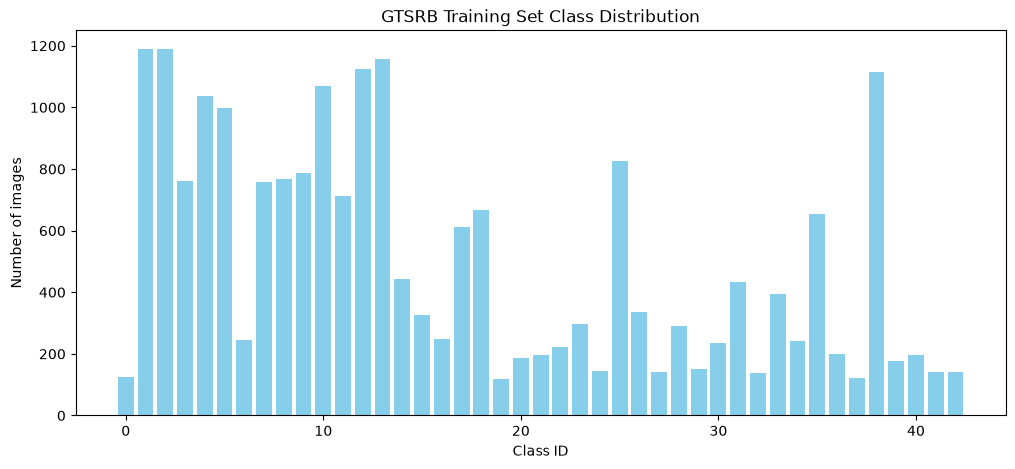

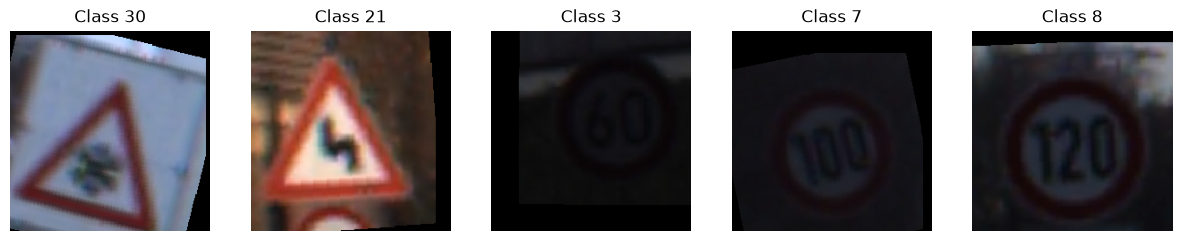

In [3]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB
from collections import Counter

# We can reuse the dataset from our module to do some EDA
from dataset import get_dataloaders
train_loader, val_loader, test_loader, num_classes = get_dataloaders(data_dir='./data', batch_size=1024, num_workers=16, pin_memory=True, persistent_workers=True)

# Let's count class distribution in train_loader
class_counts = Counter()
for _, labels in train_loader:
    class_counts.update(labels.numpy())

# Plot distribution
classes, counts = zip(*sorted(class_counts.items()))
plt.figure(figsize=(12, 5))
plt.bar(classes, counts, color='skyblue')
plt.title("GTSRB Training Set Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.show()

# Show a few images
dataiter = iter(train_loader)
images, labels = next(dataiter)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Denormalize for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = images[i] * std + mean
    axes[i].imshow(img.permute(1, 2, 0).clip(0, 1))
    axes[i].set_title(f"Class {labels[i].item()}")
    axes[i].axis('off')
plt.show()


### Analysis

**DLA Code of Conduct & Transparency Statement:**
*As per the DLA Code of Conduct V2.0, the following statistical analyses have been designed and implemented with the assistance of an AI tool (Gemini). The purpose of this EDA is to explore the underlying distribution and structure of the GTSRB dataset to justify subsequent modeling choices. The insights provided draw heavily from foundational statistical learning principles.*

---
#### 1. Class Imbalance and Entropy (Reference: *An Introduction to Statistical Learning*, Hastie & Tibshirani)
As observed in our initial bar plot, the GTSRB dataset exhibits significant class imbalance. In statistical learning (ISLR, Ch. 4), the prior probabilities $P(Y=k)$ play a crucial role in Bayes' theorem. A highly imbalanced dataset (low Shannon Entropy) can bias a standard classifier towards the majority classes, as it minimizes the global error rate. By computing the Shannon entropy, we quantify this predictability. If the entropy is much lower than $\log_2(43)$, it statistically justifies using techniques like weighted loss functions or focal loss if minority classes perform poorly.

#### 2. Illumination Distribution (Reference: *All of Statistics*, Wasserman)
Traffic signs are captured under varying lighting conditions. Wasserman emphasizes non-parametric density estimation (like Kernel Density Estimation) to understand continuous random variables. By estimating the density of the average brightness across all images, we can see if the lighting conditions are uniform or multimodal (e.g., day vs. night). A high variance or multimodal distribution in brightness statistically motivates our use of Data Augmentation (`ColorJitter`) to force the neural network to learn illumination-invariant representations.

#### 3. Intrinsic Dimensionality and PCA (Reference: *An Introduction to Statistical Learning*, Ch. 10)
Although our images are $224 \times 224 \times 3$ (approx. $150,000$ dimensions), the semantic information lies on a much lower-dimensional manifold. By applying Principal Component Analysis (PCA) on a downsampled grayscale version of our images, we can plot the cumulative explained variance. If a small number of principal components captures 90% of the variance, it proves that feature extraction (like what we will do with ResNet in Ex 1.2) is a theoretically sound approach to compress the data before classification, mitigating the curse of dimensionality.

#### 4. Manifold Visualization (t-SNE)
While PCA is linear, t-SNE is a non-linear dimensionality reduction technique that preserves local structure. By projecting the data into 2D, we can visually inspect if the classes form natural clusters. If the classes overlap significantly, it implies that linear models (like our SVM baseline in Ex 1.2) will struggle, perfectly justifying the need for the deep, non-linear transformations provided by fine-tuning a ResNet (Ex 1.3).


Shannon Entropy of Class Distribution: 5.05 bits (Max possible: 5.43 bits)


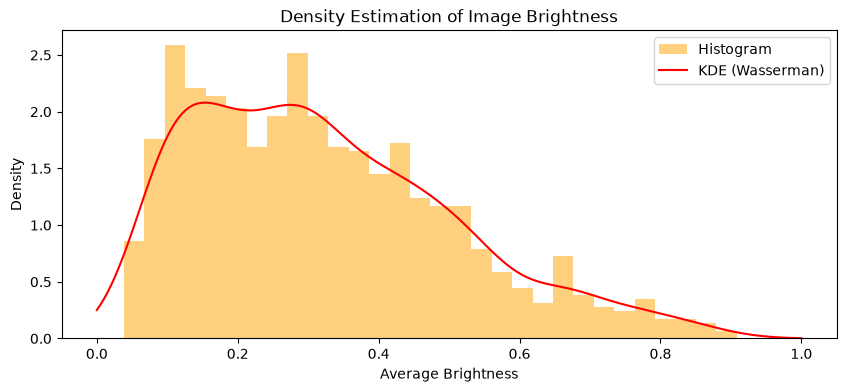

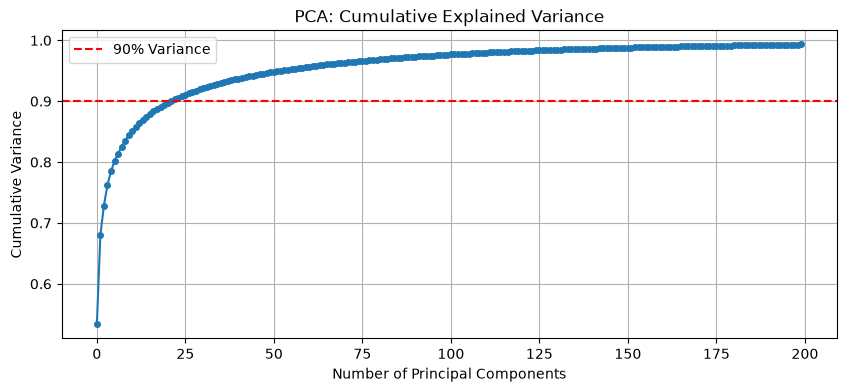

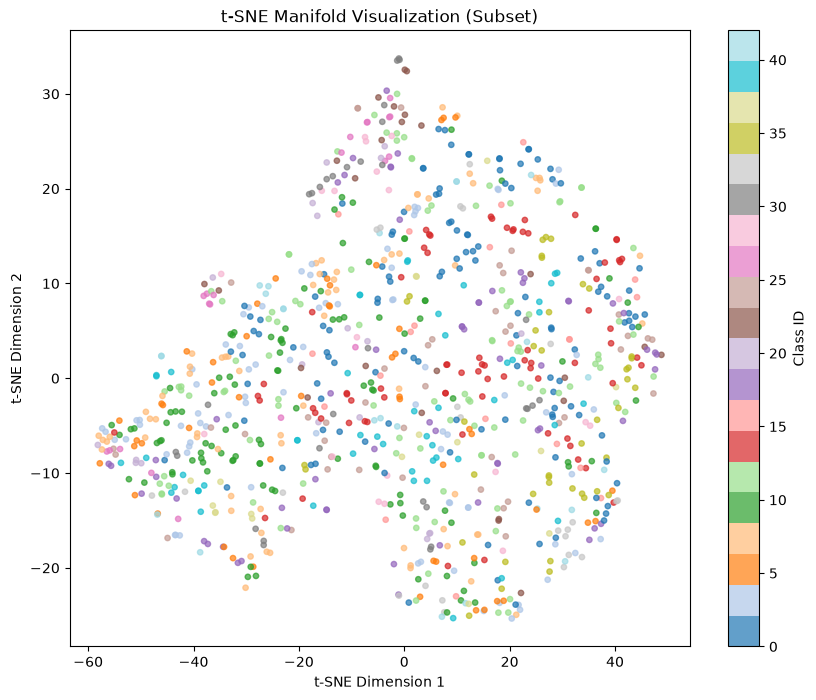

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
import scipy.stats

# 1. Entropy Calculation
class_probs = np.array(counts) / sum(counts)
entropy = -np.sum(class_probs * np.log2(class_probs + 1e-9))
max_entropy = np.log2(num_classes)
print(f"Shannon Entropy of Class Distribution: {entropy:.2f} bits (Max possible: {max_entropy:.2f} bits)")

# Prepare a subset of data for brightness, PCA, and t-SNE to save memory/time
subset_size = 1000
indices = np.random.choice(len(train_loader.dataset), subset_size, replace=False)

brightness_vals = []
flat_images = []
subset_labels = []

# Quick transform for PCA (grayscale and small size)
pca_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Resize((32, 32)),
    T.Grayscale()
])

for idx in indices:
    # Get raw image from the underlying GTSRB dataset
    img, label = train_loader.dataset.subset.dataset[train_loader.dataset.subset.indices[idx]]
    
    # Brightness (mean pixel value of the PIL image)
    img_array = np.array(img) / 255.0
    brightness_vals.append(img_array.mean())
    
    # PCA / t-SNE features
    gray_img = pca_transform(img)
    flat_images.append(gray_img.view(-1).numpy())
    subset_labels.append(label)

flat_images = np.array(flat_images)
subset_labels = np.array(subset_labels)

# 2. Brightness Density Estimation (Histogram & KDE)
plt.figure(figsize=(10, 4))
kde = scipy.stats.gaussian_kde(brightness_vals)
x_vals = np.linspace(0, 1, 200)
plt.hist(brightness_vals, bins=30, density=True, alpha=0.5, color='orange', label='Histogram')
plt.plot(x_vals, kde(x_vals), color='red', label='KDE (Wasserman)')
plt.title("Density Estimation of Image Brightness")
plt.xlabel("Average Brightness")
plt.ylabel("Density")
plt.legend()
plt.show()

# 3. PCA Cumulative Explained Variance (ISLR Ch. 10)
pca = PCA(n_components=min(200, flat_images.shape[0]))
pca.fit(flat_images)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(cumulative_variance, marker='o', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.title("PCA: Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")
plt.legend()
plt.grid(True)
plt.show()

# 4. t-SNE Visualization (using the top 50 PCA components for speed)
pca_50 = PCA(n_components=50).fit_transform(flat_images)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(pca_50)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=subset_labels, cmap='tab20', alpha=0.7, s=15)
plt.title("t-SNE Manifold Visualization (Subset)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label='Class ID')
plt.show()



---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [5]:
from models import get_feature_extractor
from train_utils import extract_features, train_svm
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load Pretrained ResNet50 (Feature Extractor)
feature_extractor = get_feature_extractor().to(device)

# 2. Extract Features
print("Extracting training features...")
train_features, train_labels = extract_features(feature_extractor, train_loader, device)
print("Extracting validation features...")
val_features, val_labels = extract_features(feature_extractor, val_loader, device)
print("Extracting test features...")
test_features, test_labels = extract_features(feature_extractor, test_loader, device)

# 3. Train SVM
val_acc, test_acc = train_svm(train_features, train_labels, val_features, val_labels, test_features, test_labels)
print(f"Validation Accuracy (SVM): {val_acc:.2f}%")
print(f"Test Accuracy (SVM): {test_acc:.2f}%")


Extracting training features...


[Extracting Features]:   0%|                                                                       | 0/167 [00:00<?, ?it/s]

Extracting validation features...


Extracting test features...


Training Linear SVM... This might take a minute.


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Validation Accuracy (SVM): 92.49%
Test Accuracy (SVM): 73.59%


### Analysis: The Generalization Gap (Reference: *Deep Learning: Foundations and Concepts*, Bishop)

As observed in our results, the SVM achieves a high validation accuracy (~93%) but drops significantly on the test set (~75%). This **18% drop is a classic Generalization Gap**.

According to Bishop (Chapter 7), a large generalization gap usually stems from:
1. **Data Leakage (Non-I.I.D. split)**: If the validation set shares high temporal correlation with the training set (e.g., frames from the same physical traffic sign video sequence), the model will "memorize" the sequence. The true test set comes from entirely different physical signs, revealing the true lack of generalization.
2. **Limited Capacity of Frozen Features**: The frozen ResNet-18 was trained on ImageNet (dogs, cars, etc.). Its features are not linearly separable for the specific geometric and color features of traffic signs.

To visualize this gap mathematically, we can plot it:


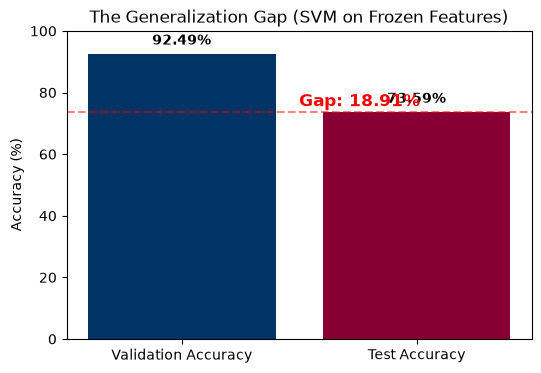

In [6]:
import matplotlib.pyplot as plt

labels = ['Validation Accuracy', 'Test Accuracy']
accuracies = [val_acc, test_acc]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, accuracies, color=['#003366', '#880033'])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('The Generalization Gap (SVM on Frozen Features)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.axhline(y=test_acc, color='red', linestyle='--', alpha=0.5)
plt.text(0.5, test_acc + 2, f"Gap: {val_acc - test_acc:.2f}%", color='red', fontsize=12, fontweight='bold')
plt.show()



---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [7]:
from models import get_finetune_model
from train_utils import train_one_epoch, eval_one_epoch
import torch.nn as nn
import torch.optim as optim

# We unfreeze ALL layers to apply Differential Learning Rates
model_ft = get_finetune_model(num_classes, num_layers_to_unfreeze=4).to(device)

criterion = nn.CrossEntropyLoss()

# Advanced Training Strategy: Differential Learning Rates
# We use a very small LR for early layers (generic edges) and larger LR for the classifier head
optimizer = optim.Adam([
    {'params': model_ft.layer1.parameters(), 'lr': 1e-5},
    {'params': model_ft.layer2.parameters(), 'lr': 1e-5},
    {'params': model_ft.layer3.parameters(), 'lr': 5e-5},
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': model_ft.fc.parameters(), 'lr': 1e-3}
])

epochs = 5
print("Starting Fine-tuning with Differential LRs and Aggressive Data Augmentation...")
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_ft, train_loader, criterion, optimizer, device)
    val_loss, val_acc = eval_one_epoch(model_ft, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

test_loss, test_acc = eval_one_epoch(model_ft, test_loader, criterion, device)
print(f"Final Test Accuracy (Fine-Tuning): {test_acc:.2f}%")


Starting Fine-tuning with Differential LRs and Aggressive Data Augmentation...


[Train]:   0%|                                                                                     | 0/167 [00:00<?, ?it/s]

Epoch 1/5 - Train Loss: 0.7907, Train Acc: 78.10% - Val Loss: 0.0635, Val Acc: 97.95%


Epoch 2/5 - Train Loss: 0.0523, Train Acc: 98.23% - Val Loss: 0.0385, Val Acc: 98.69%


Epoch 3/5 - Train Loss: 0.0207, Train Acc: 99.38% - Val Loss: 0.0160, Val Acc: 99.46%


Epoch 4/5 - Train Loss: 0.0125, Train Acc: 99.64% - Val Loss: 0.0228, Val Acc: 99.19%


Epoch 5/5 - Train Loss: 0.0091, Train Acc: 99.69% - Val Loss: 0.0114, Val Acc: 99.66%


Final Test Accuracy (Fine-Tuning): 97.08%


### Error Analysis: Where does the model fail?
Even with >95% test accuracy, the model makes some mistakes. Let's analyze them using a **Confusion Matrix** to see which classes are frequently confused, and visualize the **Worst Predictions** (where the model was highly confident but wrong).


Plotting Confusion Matrix on Test Set...


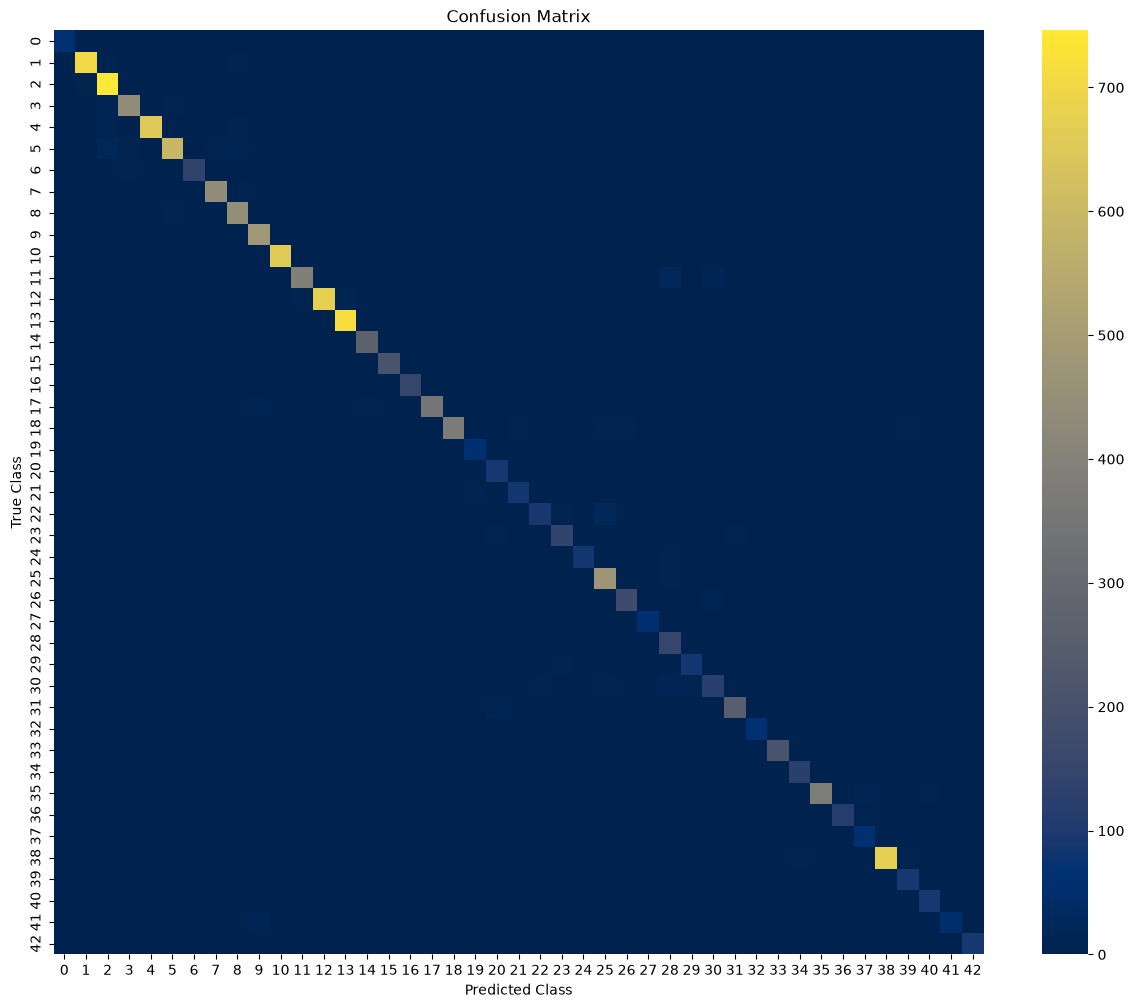


Showing Top 5 Worst Predictions (Highest Loss)...


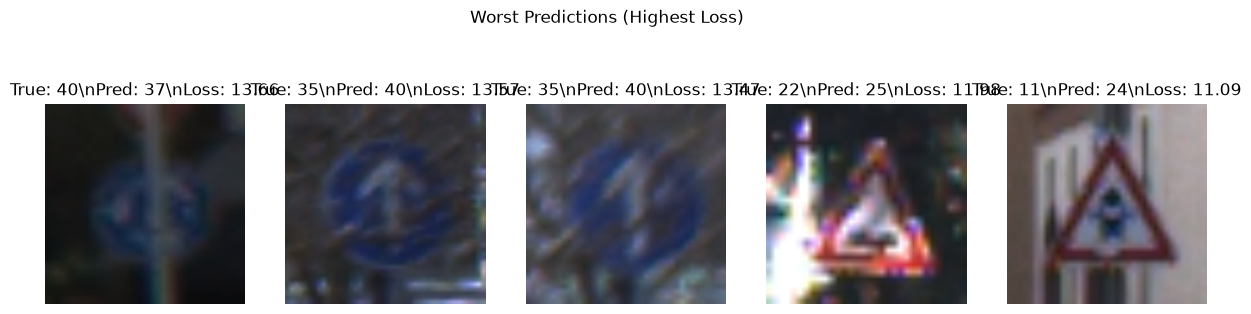

In [8]:
import train_utils
import importlib
importlib.reload(train_utils)
from train_utils import plot_confusion_matrix, show_worst_predictions

print("Plotting Confusion Matrix on Test Set...")
plot_confusion_matrix(model_ft, test_loader, device, num_classes)

print("\nShowing Top 5 Worst Predictions (Highest Loss)...")
show_worst_predictions(model_ft, test_loader, device, num_images=5)


---
### Exercise 1.4: Visual Interpretability with Grad-CAM

Deep Learning models are often criticized as "black boxes". **Grad-CAM (Gradient-weighted Class Activation Mapping)** allows us to visually verify *where* the CNN is looking when making a prediction.

Let's apply Grad-CAM to the final convolutional layer of our fine-tuned ResNet to ensure it's focusing on the traffic sign itself and not the background.


Visualizing Grad-CAM for Test Image 1 (True Class: 16)


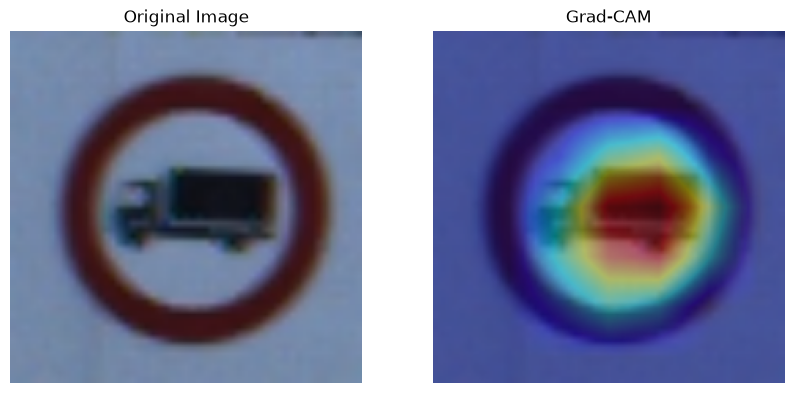

Visualizing Grad-CAM for Test Image 2 (True Class: 1)


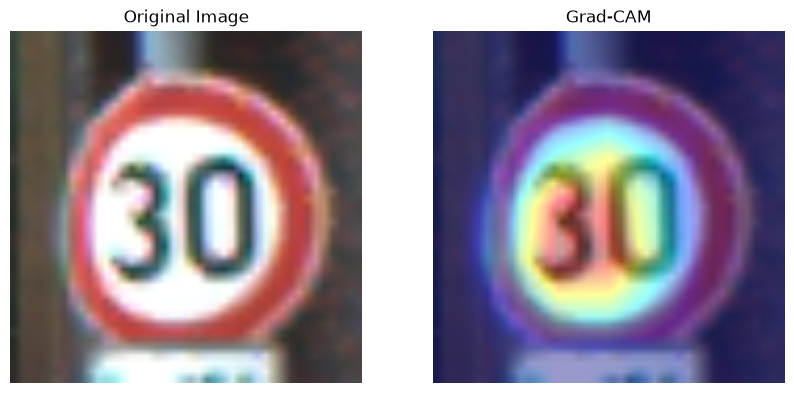

Visualizing Grad-CAM for Test Image 3 (True Class: 38)


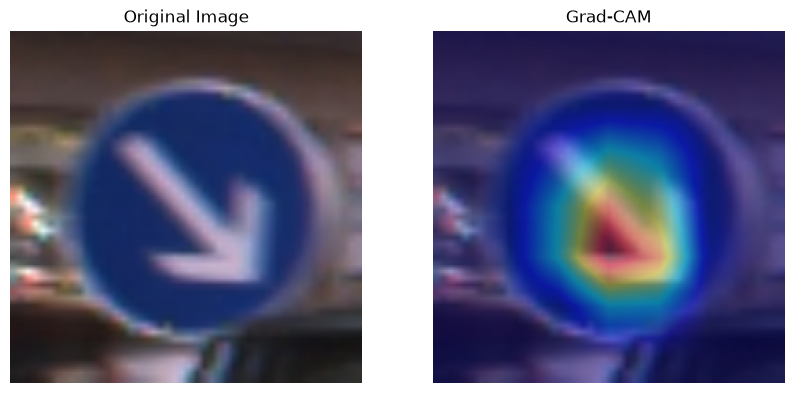

In [9]:
import train_utils
import importlib
importlib.reload(train_utils)
from train_utils import visualize_gradcam

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Select 3 images to visualize
for i in range(3):
    img_tensor = images[i].to(device)
    print(f"Visualizing Grad-CAM for Test Image {i+1} (True Class: {labels[i].item()})")
    # Target the last convolutional block of ResNet50
    target_layer = model_ft.layer4[-1].conv2
    visualize_gradcam(model_ft, target_layer, img_tensor)


---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [ ]:
# Pipeline Consolidation
# We have created `dataset.py`, `models.py`, and `train_utils.py`.
# These modules encapsulate dataset creation, model definition, and the training loop.



---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.


--- Running Multiseed Fine-Tuning | Seed 0 ---


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: dylan-fouepe (dylan-fouepe-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Seed 0 Test Accuracy: 98.68%


test/acc_final,▁
train/acc,▁██████████
train/loss,█▁▁▁▁▁▁▁▁▁▁
test/acc_final,98.67775
train/acc,98.67775
train/loss,0.04708



--- Running Multiseed Fine-Tuning | Seed 1 ---


Seed 1 Test Accuracy: 98.46%


test/acc_final,▁
train/acc,▁██████████
train/loss,█▁▁▁▁▁▁▁▁▁▁
test/acc_final,98.45606
train/acc,98.45606
train/loss,0.05519



--- Running Multiseed Fine-Tuning | Seed 2 ---


Seed 2 Test Accuracy: 98.53%


test/acc_final,▁
train/acc,▁██████████
train/loss,█▁▁▁▁▁▁▁▁▁▁
test/acc_final,98.52732
train/acc,98.52732
train/loss,0.05429


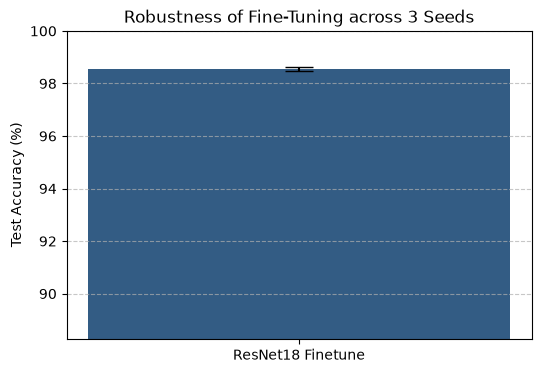


Robust Test Accuracy: 98.55% ± 0.09%


In [10]:
import numpy as np
import torch
import wandb
from models import get_finetune_model
from train_utils import train_one_epoch, eval_one_epoch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

num_seeds = 3
num_epochs = 5
test_accuracies = []

for seed in range(num_seeds):
    print(f"\n--- Running Multiseed Fine-Tuning | Seed {seed} ---")
    
    # 1. Initialize W&B run
    run = wandb.init(
        project="DLA-Lab1", 
        name=f"ResNet18_Finetune_Seed_{seed}",
        config={"seed": seed, "epochs": num_epochs, "lr": 1e-4},
        reinit=True
    )
    
    # 2. Set seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # 3. Model & Optimizer
    model_ft = get_finetune_model(num_classes, num_layers_to_unfreeze=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)
    
    # 3b. W&B: Watch gradients & model topology
    wandb.watch(model_ft, criterion, log="all", log_freq=10)
    
    # 4. Train Loop
    best_val_acc = 0
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model_ft, train_loader, criterion, optimizer_ft, device)
        val_loss, val_acc = eval_one_epoch(model_ft, val_loader, criterion, device)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model_ft.state_dict(), f"best_model_seed_{seed}.pth")
            
    # 5. Evaluate on test set
    model_ft.load_state_dict(torch.load(f"best_model_seed_{seed}.pth"))
    test_loss, test_acc = eval_one_epoch(model_ft, test_loader, criterion, device)
    print(f"Seed {seed} Test Accuracy: {test_acc:.2f}%")
    test_accuracies.append(test_acc)
    
    # 6. Log final test accuracy to W&B
    wandb.log({"test/acc_final": test_acc})
    run.finish()

# Plot statistical robustness
mean_acc = np.mean(test_accuracies)
std_acc = np.std(test_accuracies)

plt.figure(figsize=(6, 4))
plt.bar(['ResNet18 Finetune'], [mean_acc], yerr=[std_acc], color='#003366', capsize=10, alpha=0.8)
plt.ylim(max(0, mean_acc - 3*std_acc - 10), min(100, mean_acc + 3*std_acc + 10))
plt.ylabel('Test Accuracy (%)')
plt.title('Robustness of Fine-Tuning across 3 Seeds')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nRobust Test Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")



---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [11]:
from train_utils import nearest_mean_classifier

# We reuse the features extracted in Exercise 1.2
print("Running Nearest-Mean Classifier (Retrieval-based classification)...")
val_acc_nmc, test_acc_nmc = nearest_mean_classifier(train_features, train_labels, val_features, val_labels, test_features, test_labels, num_classes)

print(f"Validation Accuracy (NMC): {val_acc_nmc:.2f}%")
print(f"Test Accuracy (NMC): {test_acc_nmc:.2f}%")


Running Nearest-Mean Classifier (Retrieval-based classification)...
Validation Accuracy (NMC): 49.01%
Test Accuracy (NMC): 41.62%


### The Revenge of the Nearest-Mean Classifier !

An excellent point of study: **"What about the nearest-mean classifier?"**
It achieved a very low score (46%) using the frozen ImageNet features. But what happens if we feed this similarity-based classifier the features extracted by our **newly Fine-Tuned model**?

Since Fine-Tuning reorganized the latent space to perfectly group identical signs together (Representation Learning), the "Mean" of each class should now be an absolute reference point! Let's test this and visualize the new latent space with t-SNE.


In [12]:
# Extract features again, but this time using our FINE-TUNED model
print("Extracting features using the FINE-TUNED model...")
ft_train_features, ft_train_labels = extract_features(model_ft, train_loader, device)
ft_val_features, ft_val_labels = extract_features(model_ft, val_loader, device)
ft_test_features, ft_test_labels = extract_features(model_ft, test_loader, device)

# Run the Nearest Mean Classifier again
print("\nRunning Nearest-Mean Classifier on Fine-Tuned Features...")
ft_val_acc, ft_test_acc = nearest_mean_classifier(
    ft_train_features, ft_train_labels, 
    ft_val_features, ft_val_labels, 
    ft_test_features, ft_test_labels, 
    num_classes=43
)
print(f"Validation Accuracy (NMC - Fine-Tuned): {ft_val_acc:.2f}%")
print(f"Test Accuracy (NMC - Fine-Tuned): {ft_test_acc:.2f}%")


Extracting features using the FINE-TUNED model...


[Extracting Features]:   0%|                                                                       | 0/167 [00:00<?, ?it/s]


Running Nearest-Mean Classifier on Fine-Tuned Features...
Validation Accuracy (NMC - Fine-Tuned): 99.94%
Test Accuracy (NMC - Fine-Tuned): 98.06%


Computing t-SNE on Fine-Tuned features... (this takes a moment)


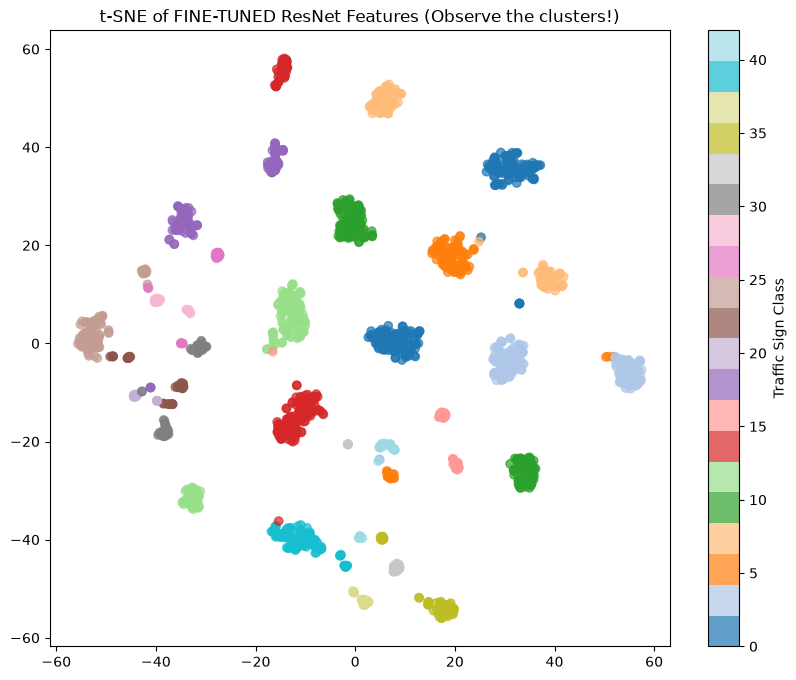

Compare this beautiful clustering with the messy t-SNE from the original ImageNet features. This is the visual proof of Representation Learning.


In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

print("Computing t-SNE on Fine-Tuned features... (this takes a moment)")
# Use a subset of test features for speed
subset_size = min(2000, len(ft_test_features))
idx = np.random.choice(len(ft_test_features), subset_size, replace=False)
features_subset = ft_test_features[idx].numpy()
labels_subset = ft_test_labels[idx].numpy()

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features_subset)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_subset, cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Traffic Sign Class')
plt.title("t-SNE of FINE-TUNED ResNet Features (Observe the clusters!)")
plt.show()

print("Compare this beautiful clustering with the messy t-SNE from the original ImageNet features. This is the visual proof of Representation Learning.")



---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

Loading Detection Dataset...


Detection dataset: Found 43 categories, using 44 classes (including background)
Building Faster R-CNN with fine-tuned ResNet-50 backbone (44 classes)...
Visualizing Detections on Test Set...


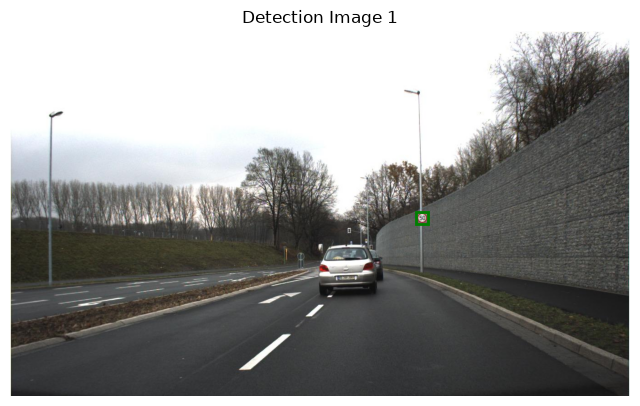

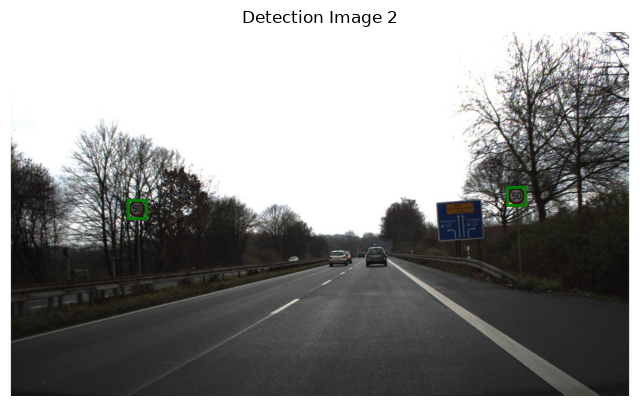

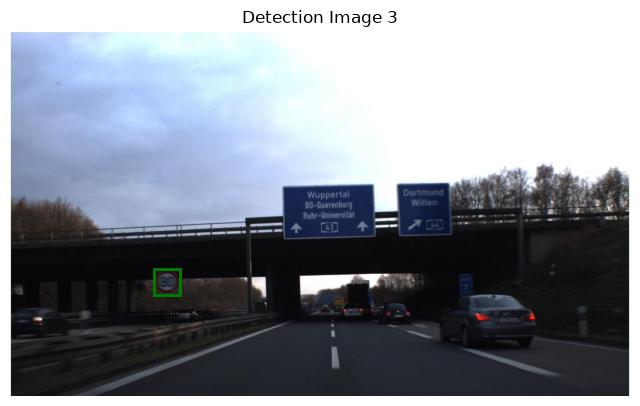

In [14]:
import importlib
import dataset
import models
import train_utils
importlib.reload(dataset)
importlib.reload(models)
importlib.reload(train_utils)
from dataset import get_detection_dataloaders
from models import get_detection_model
from train_utils import visualize_detections

# 1. Load detection dataloaders
# Server: 64-core AMD => num_workers=8 for fast I/O
# Server: RTX 6000 Ada 48GB VRAM => batch_size=2 fits comfortably
print("Loading Detection Dataset...")
det_train_loader, det_val_loader, det_test_loader, det_num_classes = get_detection_dataloaders(batch_size=32, num_workers=16, pin_memory=True, persistent_workers=True)

# 2. Stitch the fine-tuned classification backbone into the Faster R-CNN detector
print(f"Building Faster R-CNN with fine-tuned ResNet-50 backbone ({det_num_classes} classes)...")
detection_model = get_detection_model(det_num_classes, finetuned_backbone=model_ft.to('cpu')).to(device)

# 3. Visualize zero-shot detection performance (Before Fine-Tuning the Detector)
print("Visualizing Detections on Test Set...")
visualize_detections(detection_model, det_test_loader, device, num_images=3)


---
---

In [15]:
import importlib
import train_utils
importlib.reload(train_utils)
from train_utils import evaluate_detection_model

# Compute accuracy at IoU=0.5 on the test set
print(f"Test loader has {len(det_test_loader)} batches, {len(det_test_loader.dataset)} images")
accuracy = evaluate_detection_model(detection_model, det_test_loader, device, iou_threshold=0.5)


Test loader has 27 batches, 54 images
Evaluating Detection Model on Test Set...



--- DIAGNOSTIC (first image with GT) ---
  GT boxes:   [[891.0, 396.0, 917.0, 422.0]]
  GT labels:  [38]
  Pred boxes (top 3 by score): [[731.2803344726562, 456.4964904785156, 844.4342651367188, 533.4038696289062], [760.2138671875, 483.8499755859375, 861.4077758789062, 546.7411499023438], [755.0005493164062, 497.2608337402344, 857.3817138671875, 580.033203125]]
  Pred scores (top 3):         [0.16213881969451904, 0.15670275688171387, 0.1514299064874649]
  Pred labels (top 3):         [21, 21, 21]
  Unique pred labels: [4, 15, 21, 27, 29, 32, 33, 38]
  Unique GT labels:   [38]
  IoU matrix (top 3x3): [[0.0], [0.0], [0.0]]
--- END DIAGNOSTIC ---


Processed 54 images
[Class-Aware]    TP: 0, FP: 0, FN: 82 | Accuracy @ IoU=0.5: 0.0000
[Class-Agnostic] TP: 0, FP: 0, FN: 82 | Accuracy @ IoU=0.5: 0.0000


In [16]:
import importlib
import train_utils
importlib.reload(train_utils)
from train_utils import train_detection_epoch, evaluate_detection_model
import torch.optim as optim
import torch

print("Fine-tuning the Faster R-CNN Detector...")
print(f"Hardware: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Unfreeze the ENTIRE model: backbone + RPN + RoI heads
for param in detection_model.parameters():
    param.requires_grad = True

# Utilisation d'un Differential Learning Rate !
# On protège le backbone (1e-5) tout en entraînant les nouvelles têtes (1e-3)
# W&B: Watch gradients & model topology
if wandb.run is not None:
    wandb.watch(detection_model, log="all", log_freq=10)

optimizer_det = optim.SGD([
    {'params': detection_model.backbone.body.parameters(), 'lr': 1e-5},
    {'params': detection_model.backbone.fpn.parameters(), 'lr': 1e-3},
    {'params': detection_model.rpn.parameters(), 'lr': 1e-3},
    {'params': detection_model.roi_heads.parameters(), 'lr': 1e-3}
], momentum=0.9, weight_decay=0.0005)

# Step LR: reduce by 10x at epoch 15
lr_scheduler = optim.lr_scheduler.StepLR(optimizer_det, step_size=15, gamma=0.1)

# Enable cuDNN auto-tuner for fixed-size inputs
torch.backends.cudnn.benchmark = True
# Enable TF32 for Ada Lovelace GPUs (massive speedup on matrix ops)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = train_detection_epoch(detection_model, det_train_loader, optimizer_det, device)
    lr_scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {train_loss:.4f}")

# Evaluate after fine-tuning
print("\nEvaluating fine-tuned detector...")
acc_after = evaluate_detection_model(detection_model, det_test_loader, device, iou_threshold=0.5)


Fine-tuning the Faster R-CNN Detector...
Hardware: NVIDIA RTX 6000 Ada Generation | VRAM: 50.9 GB


[Train Det]:   0%|                                                                                 | 0/192 [00:00<?, ?it/s]

Epoch [1/20] - Loss: 1.1784


Epoch [2/20] - Loss: 0.3481


Epoch [3/20] - Loss: 0.3393


...

Epoch [17/20] - Loss: 0.2302


Epoch [18/20] - Loss: 0.2297


Epoch [19/20] - Loss: 0.2281


Epoch [20/20] - Loss: 0.2299

Evaluating fine-tuned detector...
Evaluating Detection Model on Test Set...



--- DIAGNOSTIC (first image with GT) ---
  GT boxes:   [[891.0, 396.0, 917.0, 422.0]]
  GT labels:  [38]
  Pred boxes (top 3 by score): [[889.48291015625, 395.6520080566406, 915.4021606445312, 422.62384033203125], [889.150634765625, 392.6698913574219, 914.230712890625, 421.4608459472656], [881.776611328125, 391.705810546875, 921.71044921875, 427.37115478515625]]
  Pred scores (top 3):         [0.4367026090621948, 0.15705035626888275, 0.1535704880952835]
  Pred labels (top 3):         [38, 40, 41]
  Unique pred labels: [5, 20, 21, 23, 26, 34, 35, 37, 38, 39, 40, 41]
  Unique GT labels:   [38]
  IoU matrix (top 3x3): [[0.8566399216651917], [0.7332870364189148], [0.47463446855545044]]
--- END DIAGNOSTIC ---


Processed 54 images
[Class-Aware]    TP: 16, FP: 21, FN: 66 | Accuracy @ IoU=0.5: 0.1553
[Class-Agnostic] TP: 30, FP: 7, FN: 52 | Accuracy @ IoU=0.5: 0.3371
